# Análisis de SVM e Isolation Forest con datos clasificados

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import umap

/home/isaac07/Proyectos/python/copate-26/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Importamos el Dataframe

In [82]:
#Importamos el que paso Vinicio ( ya correctamente etiquetado)
df_raw = pd.read_csv('Resultado_Procesado.csv')

# Quitamos las columnas que NO se necesitan (la ip del plc y una que se generó sola)
df_raw = df_raw.drop(['Unnamed: 0', 'plc_ip'], axis=1)

# La columna de tiempo a datetime
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

defectos_dict= {
    'Splatter': 0,
    'Gap': 1,
    'Terminal Perforada': 2,
    'Busbar Perforada': 3,
    'MetalFlake': 4,
    'Busbar Desalineada': 5,
    'Terminal/Kostal Desalineada': 6,
    'Faltante de Busbar/Terminal': 7,
    'Faltante de Terminal/Kostal': 8,
    'Weld projection sin derretir': 9
    # 'NO ANOMALIA': -1
}

df_raw['Defecto'] = df_raw['Defecto'].map(defectos_dict).fillna(-1).astype('Int64')




# =================================================#

# Elegimos un único df (el clasico sch1-est140)
estacion = 140
schedule = 'Sch1'

# Procesar el df_140
df_140 = df_raw[(df_raw['estacion'] == estacion) & (df['sch'] == schedule)]
df_140.drop(['estacion','sch'],axis=1)
df_140.reset_index(drop=True)

df_140['Defecto'].value_counts()


Defecto
-1    495
5      25
6       2
4       1
7       1
Name: count, dtype: Int64

## Quitamos los nombres de los errores de soldadura por otros (evitar str)
Además, quitamos los valores que no necesitamos como PalletId, el Periodo (Id del periodo el que se inspeccionó) y el id.

In [58]:
defectos_dict= {
    'Splatter': 0,
    'Gap': 1,
    'Terminal Perforada': 2,
    'Busbar Perforada': 3,
    'MetalFlake': 4,
    'Busbar Desalineada': 5,
    'Terminal/Kostal Desalineada': 6,
    'Faltante de Busbar/Terminal': 7,
    'Faltante de Terminal/Kostal': 8,
    'Weld projection sin derretir': 9
}

df_140['Defecto'] = df_140['Defecto'].map(defectos_dict).fillna(-1).astype('Int64')

df_140['Defecto'].value_counts()

df_140 = df_140.drop(['id','sch','estacion','PalletId','Periodo','Inspeccion','DifMinutos'],axis=1)

df_140.info()

<class 'pandas.DataFrame'>
Index: 524 entries, 0 to 3694
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       524 non-null    datetime64[us]
 1   distancia       524 non-null    float64       
 2   fuerza          524 non-null    int64         
 3   ampers          524 non-null    float64       
 4   volts           524 non-null    float64       
 5   watts           524 non-null    float64       
 6   Electrodecount  524 non-null    int64         
 7   Defecto         524 non-null    Int64         
dtypes: Int64(1), datetime64[us](1), float64(4), int64(2)
memory usage: 37.4 KB


## Preprocesamiento (escalar)

In [83]:
features = ['distancia', 'fuerza', 'ampers', 'volts', 'watts', 'Electrodecount']
X = df_140[features].fillna(0)
y = (df_140['Defecto'] != -1).astype(int)  # 1 = defecto, 0 = normal

scaler = StandardScaler()
scaler.fit(X[y == 0])          # solo aprende la distribución de registros normales
X_scaled = scaler.transform(X) # transforma todo

data

,distancia,fuerza,ampers,volts,watts,Electrodecount,Defecto
0,0.391,97,10.67,2.4,5.78,351,5
5,0.394,97,10.57,2.4,5.89,353,-1
11,0.377,98,10.55,2.5,5.85,355,-1
20,0.498,96,10.62,2.5,5.91,357,-1
27,0.503,97,10.57,2.4,5.90,359,-1
...,...,...,...,...,...,...,...
3660,0.425,97,10.84,2.7,7.63,805,-1
3668,0.477,97,10.84,2.5,7.18,807,-1
3681,0.492,96,10.84,2.6,7.49,809,-1
3688,0.453,97,10.91,2.5,7.20,811,-1


## Isolation forest y SVM

In [84]:
df_final = X.copy()
df_final['target'] = y
print("Distribución de clases:")
print(df_final['target'].value_counts())

Distribución de clases:
target
0    495
1     29
Name: count, dtype: int64


In [85]:
from sklearn.metrics import classification_report

#para entrenar. osea los normales nomas
X_train = X_scaled[y == 0]

# isolation forest
iso = IsolationForest(contamination=0.06, n_estimators=100, random_state=42)
iso.fit(X_train)
pred_iso = (iso.predict(X_scaled) == -1).astype(int)  # -1 → anomalía → 1

# SVM
svm = OneClassSVM(nu=0.06, kernel='rbf', gamma='scale')
svm.fit(X_train)
pred_svm = (svm.predict(X_scaled) == -1).astype(int)

# mostrar resultados
print("=== Isolation Forest ===")
print(classification_report(y, pred_iso, target_names=['normal','defecto']))

print("=== One-Class SVM ===")
print(classification_report(y, pred_svm, target_names=['normal','defecto']))

=== Isolation Forest ===
              precision    recall  f1-score   support

      normal       0.95      0.94      0.95       495
     defecto       0.14      0.17      0.16        29

    accuracy                           0.90       524
   macro avg       0.55      0.56      0.55       524
weighted avg       0.91      0.90      0.90       524

=== One-Class SVM ===
              precision    recall  f1-score   support

      normal       0.95      0.93      0.94       495
     defecto       0.12      0.17      0.14        29

    accuracy                           0.89       524
   macro avg       0.54      0.55      0.54       524
weighted avg       0.90      0.89      0.90       524



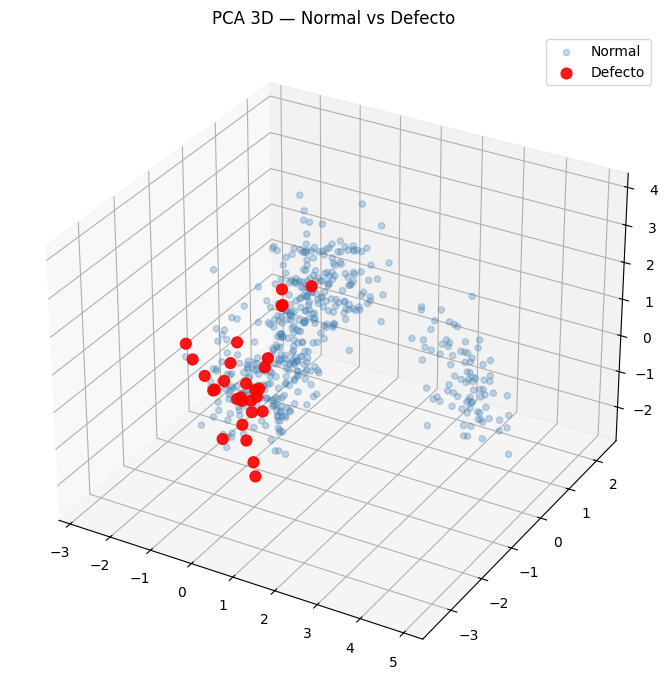

Varianza explicada: 86.3%


In [86]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca3[y==0, 0], X_pca3[y==0, 1], X_pca3[y==0, 2],
           label='Normal', alpha=0.3, s=20, c='steelblue')
ax.scatter(X_pca3[y==1, 0], X_pca3[y==1, 1], X_pca3[y==1, 2],
           label='Defecto', alpha=0.9, s=60, c='red')

ax.set_title('PCA 3D — Normal vs Defecto')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Varianza explicada: {pca3.explained_variance_ratio_.sum()*100:.1f}%")

/home/isaac07/Proyectos/python/copate-26/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


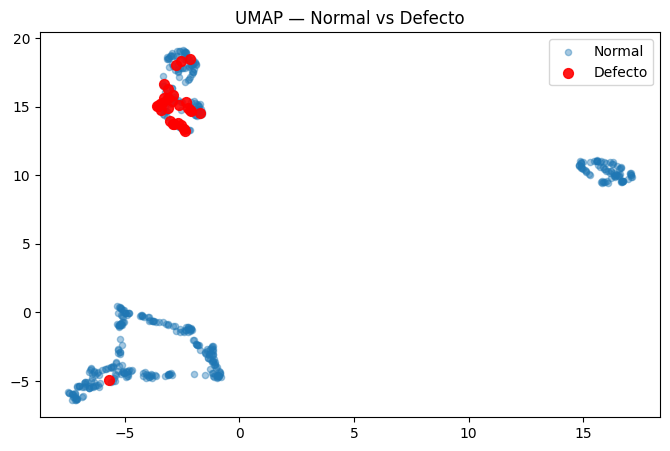

In [87]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_umap[y==0, 0], X_umap[y==0, 1], label='Normal', alpha=0.4, s=20)
plt.scatter(X_umap[y==1, 0], X_umap[y==1, 1], label='Defecto', alpha=0.9, s=50, color='red')
plt.legend()
plt.title('UMAP — Normal vs Defecto')
plt.show()

## Traer los modelos antiguos y usarlos para comparar

In [95]:
import joblib

# Cargar modelo y scaler viejos
modelo = joblib.load('modelo_iso_est140Sch1.pkl')
scaler_viejo = joblib.load('scaler_est140Sch1.pkl')

# Filtrar datos de Vinicio para est140/Sch1
col_interes = ['distancia', 'fuerza', 'ampers', 'volts', 'watts']

df_vinicio = df_raw[(df_raw['estacion'] == estacion) & (df_raw['sch'] == schedule)].copy()
df_vinicio['y_real'] = (df_vinicio['Defecto'] != -1).astype(int)  # etiquetas reales


print(f"Registros est140/Sch1: {len(df_vinicio)}")
print(f"Defectos reales: {df_vinicio['y_real'].sum()}")

# Escalar con el scaler viejo
X_vinicio = scaler_viejo.transform(df_vinicio[col_interes])

# Predecir
preds = modelo.predict(X_vinicio)
df_vinicio['y_pred'] = (preds == -1).astype(int)

# Evaluar
from sklearn.metrics import classification_report
print(classification_report(df_vinicio['y_real'], df_vinicio['y_pred'],
                             target_names=['normal', 'defecto']))

Registros est140/Sch1: 524
Defectos reales: 29
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00       495
     defecto       0.06      1.00      0.10        29

    accuracy                           0.06       524
   macro avg       0.03      0.50      0.05       524
weighted avg       0.00      0.06      0.01       524



/home/isaac07/Proyectos/python/copate-26/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaac07/Proyectos/python/copate-26/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaac07/Proyectos/python/copate-26/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [96]:
import numpy as np
print(f"Predicciones únicas: {np.unique(preds)}")
print(f"Anomalías predichas: {(preds == -1).sum()}")
print(f"Normales predichas:  {(preds == 1).sum()}")
print(f"y_real únicos: {df_vinicio['y_real'].unique()}")

Predicciones únicas: [-1]
Anomalías predichas: 524
Normales predichas:  0
y_real únicos: [1 0]


In [97]:
print(df_vinicio['Defecto'].value_counts())
print(df_vinicio['Defecto'].dtype)
print(type(df_vinicio['Defecto'].iloc[0]))

Defecto
-1    495
5      25
6       2
4       1
7       1
Name: count, dtype: Int64
Int64
<class 'numpy.int64'>


In [1]:
df

NameError: name 'df' is not defined

In [3]:
df_prueba = pd.read_csv('WeldParameters30Enero_07Abril.csv')

In [4]:
df_prueba

,id,timestamp,distancia,fuerza,ampers,volts,watts,estacion,sch,plc_ip,PalletId,Electrodecount
0,33,2026-01-30 10:39:05,0.318,94.0,10.94,2.1,7.43,150,Sch1,172.16.15.1,1,11
1,34,2026-01-30 10:39:15,0.385,121.0,12.50,2.6,9.98,155,Sch2,172.16.15.1,21,9
2,35,2026-01-30 10:39:18,0.297,95.0,10.79,2.2,7.03,150,Sch2,172.16.15.1,22,12
3,36,2026-01-30 10:39:19,0.383,123.0,13.60,2.7,11.35,155,Sch1,172.16.15.1,21,10
4,37,2026-01-30 10:39:22,0.317,94.0,11.01,2.0,7.47,150,Sch1,172.16.15.1,22,13
...,...,...,...,...,...,...,...,...,...,...,...,...
983537,983570,2026-04-07 03:48:31,0.310,94.0,10.55,2.5,9.36,150,Sch1,172.16.15.1,16,610
983538,983571,2026-04-07 03:48:49,0.385,126.0,11.67,2.7,10.04,155,Sch2,172.16.15.1,-2,607
983539,983572,2026-04-07 03:48:53,0.375,126.0,9.98,2.3,8.39,155,Sch1,172.16.15.1,-2,608
983540,983573,2026-04-07 03:49:15,0.371,124.0,11.57,2.6,9.97,155,Sch2,172.16.15.1,11,609


In [5]:
df_prueba = pd.read_csv('Weld_Data_IBC2.csv')
df_prueba

,Unnamed: 0,id,timestamp,distancia,fuerza,ampers,volts,watts,estacion,sch,...,FuerzaLo,DistLo,AmpsLo,VoltsLo,WattsLo,FuerzaHi,DistHi,AmpsHi,VoltsHi,WattsHi
0,0,1248833,2025-09-02 11:41:37,0.411,105,10.30,2.4,0.06,140,Sch1,...,97,0.25,10.5,1,0.01,117,0.56,12.5,4.0,0.10
1,1,1248834,2025-09-02 11:41:40,0.358,108,12.43,2.5,0.05,145,Sch1,...,95,0.25,10.5,1,0.01,116,0.50,12.5,4.0,0.15
2,2,1248835,2025-09-02 11:41:41,0.331,91,13.14,1.9,0.05,150,Sch2,...,75,0.25,11.0,1,0.00,100,0.55,13.0,3.0,0.20
3,3,1248836,2025-09-02 11:41:41,0.391,91,12.67,2.3,0.09,155,Sch2,...,80,0.30,11.0,1,0.00,100,0.60,13.0,3.0,0.20
4,4,1248837,2025-09-02 11:41:44,0.435,89,11.30,2.1,0.08,155,Sch2,...,80,0.30,11.0,1,0.00,100,0.60,13.0,3.0,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953196,953196,2202029,2025-10-21 13:46:29,0.372,104,11.47,2.7,0.06,145,Sch2,...,95,0.25,12.0,1,0.01,115,0.55,14.0,4.0,0.15
953197,953197,2202030,2025-10-21 13:46:34,0.382,106,12.33,2.5,0.05,145,Sch1,...,95,0.23,10.5,1,0.01,115,0.55,12.5,4.0,0.15
953198,953198,2202031,2025-10-21 13:46:35,0.284,91,10.81,2.6,0.07,150,Sch2,...,85,0.25,12.5,1,0.00,105,0.55,14.5,4.0,0.20
953199,953199,2202032,2025-10-21 13:46:35,0.384,99,12.26,2.3,0.07,155,Sch2,...,80,0.25,10.5,1,0.00,100,0.55,12.5,4.0,0.20
